# Utforskning: elpris och väder

Det här är notebooken som modellen i `model/model.pkl` togs fram i. Den är inte
en färdig analys utan en rundtur i datan, med vissa problem flaggade.

**Kör den innan ni börjar bygga.** Nästan varje beslut ni ska fatta i
sprint 1 har sin grund i något som syns här.

> **Datan i `data/` är syntetisk tills ni byter ut den.** Kör
> `uv run python data/fetch_historik.py` för att få riktiga mätvärden. Formen är
> densamma, men siffrorna är påhittade. Dra inga slutsatser om svensk
> elmarknad från den här filen förrän ni hämtat riktiga data.

In [1]:
import zoneinfo
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "model" else Path.cwd()
STOCKHOLM = zoneinfo.ZoneInfo("Europe/Stockholm")

AREA = "SE3"          # byt till ert tilldelade elområde
STATION = 98230       # och den station ni valt eller fick tilldelad

pd.set_option("display.width", 120)

## 1. Råa priser

In [2]:
priser = pd.read_csv(ROOT / "data" / "historik_elpris.csv.gz")
print(priser.shape)
priser.head()

(165477, 6)


,price_area,SEK_per_kWh,EUR_per_kWh,EXR,time_start,time_end
0,SE1,0.09823,0.00857,11.465991,2024-08-01T00:00:00+02:00,2024-08-01T01:00:00+02:00
1,SE1,0.11955,0.01043,11.465991,2024-08-01T01:00:00+02:00,2024-08-01T02:00:00+02:00
2,SE1,0.11316,0.00987,11.465991,2024-08-01T02:00:00+02:00,2024-08-01T03:00:00+02:00
3,SE1,0.05250,0.00458,11.465991,2024-08-01T03:00:00+02:00,2024-08-01T04:00:00+02:00
4,SE1,0.10633,0.00927,11.465991,2024-08-01T04:00:00+02:00,2024-08-01T05:00:00+02:00


Fem kolumner från datakällan, plus `price_area` som hämtningsskriptet lagt till.
`time_start` är lokal svensk tid med UTC-offset. Notera att offseten
byter mellan `+01:00` och `+02:00` över året (beroende på sommar- o vintertid).

In [3]:
priser["offset"] = priser["time_start"].str[-6:]
print(priser["offset"].value_counts())

# Parsa med utc=True först. Gör man inte det får man en object-kolumn med
# blandade offsets, som sorterar fel över sommartidsskiftet.
priser["ts_utc"] = pd.to_datetime(priser["time_start"], utc=True, format="ISO8601")
priser["ts_local"] = priser["ts_utc"].dt.tz_convert(STOCKHOLM)
priser["datum"] = priser["ts_local"].dt.date

se = priser[priser["price_area"] == AREA].copy()
print(f"\n{AREA}: {len(se):,} rader, {se['datum'].nunique():,} dygn")

offset
+02:00    91483
+01:00    73994
Name: count, dtype: int64

SE3: 41,371 rader, 750 dygn


## 2. Första fällan: antalet prispunkter per dygn

Om ni gjorde självstudieuppgiften har ni redan sett det här. Sverige gick
från timpris till kvartspris **1 oktober 2025**. Före det datumet var det 24
punkter per dygn, nu är det 96.

23       1
24     418
25       7
92       1
96     287
97      33
98       2
100      1
Name: count, dtype: int64


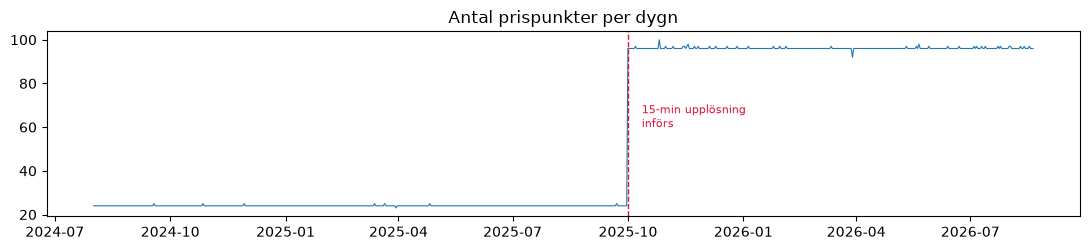

In [4]:
per_dygn = se.groupby("datum").size()
print(per_dygn.value_counts().sort_index())

fig, ax = plt.subplots(figsize=(11, 2.6))
ax.plot(pd.to_datetime(per_dygn.index), per_dygn.values, lw=0.8)
ax.axvline(pd.Timestamp("2025-10-01"), color="crimson", ls="--", lw=1)
ax.set_title("Antal prispunkter per dygn")
ax.annotate("15-min upplösning\ninförs", xy=(pd.Timestamp("2025-10-01"), 60),
            xytext=(10, 0), textcoords="offset points", color="crimson", fontsize=8)
plt.tight_layout()

De udda värdena (23, 25, 92, 100) är sommartid. Sista söndagen i mars
har 23 timmar, sista söndagen i oktober har 25.  

Hitta andra sådana:

In [5]:
udda = per_dygn[~per_dygn.isin([24, 96])]
print(udda)

datum
2024-09-18     25
2024-10-27     25
2024-11-29     25
2025-03-13     25
2025-03-21     25
2025-03-30     23
2025-04-26     25
2025-09-22     25
2025-10-07     97
2025-10-26    100
2025-10-31     97
2025-11-06     97
2025-11-14     97
2025-11-15     97
2025-11-17     97
2025-11-18     98
2025-11-23     97
2025-11-26     97
2025-12-05     97
2025-12-10     97
2025-12-19     97
2025-12-27     97
2026-01-05     97
2026-01-25     97
2026-01-30     97
2026-02-04     97
2026-03-12     97
2026-03-29     92
2026-05-11     97
2026-05-19     97
2026-05-21     98
2026-05-29     97
2026-06-13     97
2026-06-22     97
2026-07-04     97
2026-07-06     97
2026-07-10     97
2026-07-13     97
2026-07-23     97
2026-07-25     97
2026-08-01     97
2026-08-02     97
2026-08-10     97
2026-08-13     97
2026-08-17     97
dtype: int64


## 3. Dubbletter

Omhämtning lämnar exakta dubbletter efter sig. De måste bort före
aggregering, annars viktas en timme dubbelt i dygnsmedelvärdet.

In [6]:
dubbletter = se.duplicated(subset=["ts_utc"]).sum()
print(f"{dubbletter} dubblerade tidsstämplar")

se = se.drop_duplicates(subset=["ts_utc"], keep="first")

43 dubblerade tidsstämplar


## 4. Hur priset faktiskt ser ut

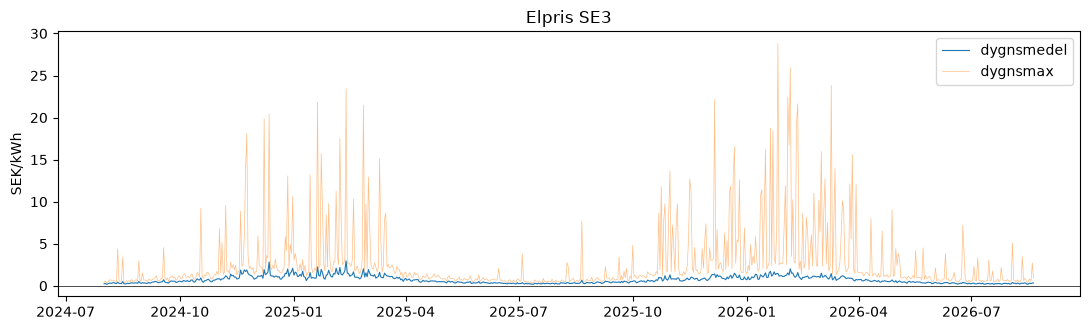

In [8]:
dygn = se.groupby("datum")["SEK_per_kWh"].agg(["mean", "max", "min"])
dygn.index = pd.to_datetime(dygn.index)

fig, ax = plt.subplots(figsize=(11, 3.4))
ax.plot(dygn.index, dygn["mean"], lw=0.8, label="dygnsmedel")
ax.plot(dygn.index, dygn["max"], lw=0.5, alpha=0.5, label="dygnsmax")
ax.axhline(0, color="k", lw=0.5)
ax.set_ylabel("SEK/kWh")
ax.legend()
ax.set_title(f"Elpris {AREA}")
plt.tight_layout()

Två saker som ställer till det:

**Negativa priser.** Soliga, blåsiga, milda timmar mitt på dagen kan faktiskt göra att priset går under noll. Det är inte mätfel.

**Spikar.** Enstaka timmar kan ligga en 10 ggr över det normala. Beroende på vilket felmått man använder kan de ha en stor inverkan.

In [ ]:
print(f"negativa prispunkter: {(se['SEK_per_kWh'] < 0).sum()}")
print(f"högsta prispunkt:     {se['SEK_per_kWh'].max():.2f} SEK/kWh")
print(f"median:               {se['SEK_per_kWh'].median():.3f} SEK/kWh")

# Hur mycket av felet bor i svansen? Andel av dygnen över 3x medianen:
tröskel = 3 * dygn["mean"].median()
print(f"\ndygn med medelpris > {tröskel:.2f}: "
      f"{(dygn['mean'] > tröskel).sum()} av {len(dygn)}")

### Dygnsprofilen

Elpriset är inte slumpmässigt över dygnet. Två toppar: morgon och
tidig kväll. Helger är billigare.

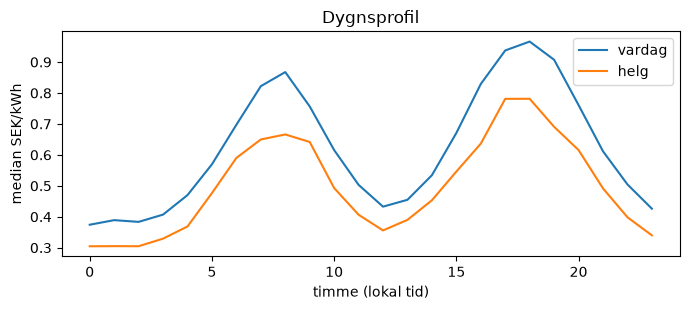

In [9]:
se["timme"] = se["ts_local"].dt.hour
se["helg"] = se["ts_local"].dt.dayofweek >= 5

profil = se.groupby(["helg", "timme"])["SEK_per_kWh"].median().unstack(0)

fig, ax = plt.subplots(figsize=(7, 3.2))
profil.plot(ax=ax)
ax.set_xlabel("timme (lokal tid)")
ax.set_ylabel("median SEK/kWh")
ax.legend(["vardag", "helg"])
ax.set_title("Dygnsprofil")
plt.tight_layout()

## 5. Vädret — och tidszonsfällan

SMHI levererar **UTC utan offsetmarkör**. Priserna är i lokal tid. Slår man
ihop dem naivt hamnar man en till två timmar fel beroende på årstid.

In [10]:
väder = pd.read_csv(ROOT / "data" / "historik_vader.csv.gz", sep=";")
väder = väder[väder["Stationsnummer"] == STATION].copy()
print(väder.shape)
väder.head()

(17488, 7)


,Stationsnummer,Stationsnamn,Datum,Tid (UTC),Lufttemperatur,Vindhastighet,Kvalitet
34517,98230,Stockholm-Observatoriekullen A,2024-07-31,22:00:00,12.1,6.4,G
34518,98230,Stockholm-Observatoriekullen A,2024-07-31,23:00:00,11.6,6.1,G
34519,98230,Stockholm-Observatoriekullen A,2024-08-01,00:00:00,11.0,6.5,G
34520,98230,Stockholm-Observatoriekullen A,2024-08-01,01:00:00,11.5,5.5,G
34521,98230,Stockholm-Observatoriekullen A,2024-08-01,02:00:00,10.2,6.3,G


In [11]:
# Notera .tz_localize("UTC") — inte tz_convert. Tidsstämplarna ÄR UTC,
# de är bara inte märkta som det.
stämpel = pd.to_datetime(väder["Datum"] + " " + väder["Tid (UTC)"])
väder["ts_utc"] = stämpel.dt.tz_localize("UTC")
väder["ts_local"] = väder["ts_utc"].dt.tz_convert(STOCKHOLM)
väder["datum"] = väder["ts_local"].dt.date

väder = väder.rename(columns={"Lufttemperatur": "temp_c", "Vindhastighet": "vind_ms"})
väder[["ts_utc", "ts_local", "temp_c", "vind_ms", "Kvalitet"]].head()

,ts_utc,ts_local,temp_c,vind_ms,Kvalitet
34517,2024-07-31 22:00:00+00:00,2024-08-01 00:00:00+02:00,12.1,6.4,G
34518,2024-07-31 23:00:00+00:00,2024-08-01 01:00:00+02:00,11.6,6.1,G
34519,2024-08-01 00:00:00+00:00,2024-08-01 02:00:00+02:00,11.0,6.5,G
34520,2024-08-01 01:00:00+00:00,2024-08-01 03:00:00+02:00,11.5,5.5,G
34521,2024-08-01 02:00:00+00:00,2024-08-01 04:00:00+02:00,10.2,6.3,G


### Luckor

Ibland saknas timmar i SMHI-data när en givare varit ur funktion. Kolla
hur många.

514 saknade timmar av 18000 (2.9%)


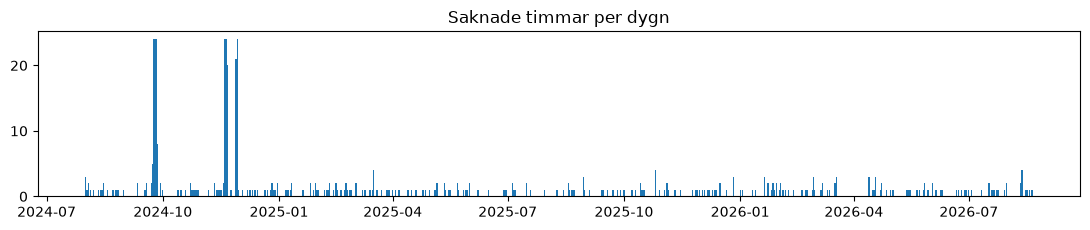

In [12]:
full = pd.date_range(väder["ts_utc"].min(), väder["ts_utc"].max(), freq="h", tz="UTC")
saknade = full.difference(pd.DatetimeIndex(väder["ts_utc"]))
print(f"{len(saknade)} saknade timmar av {len(full)} ({100*len(saknade)/len(full):.1f}%)")

# Är de utspridda eller klumpade? Det avgör om interpolering är rimligt.
if len(saknade):
    lucka = pd.Series(1, index=saknade).resample("D").sum()
    fig, ax = plt.subplots(figsize=(11, 2.4))
    ax.bar(lucka.index, lucka.values, width=1.0)
    ax.set_title("Saknade timmar per dygn")
    plt.tight_layout()

**Fråga att svara på:** enstaka saknade timmar kan man interpolera.
Ett fyra dygn långt avbrott bör man troligen inte göra det med. Var går er gräns, och
varför? .

In [13]:
# Kvalitetskoder: G = kontrollerad och godkänd, Y = misstänkt eller aggregerad.
print(väder["Kvalitet"].value_counts())
print("\nSkiljer sig Y-värdena systematiskt från G?")
print(väder.groupby("Kvalitet")["temp_c"].describe()[["count", "mean", "std"]])

Kvalitet
G    13650
Y     3838
Name: count, dtype: int64

Skiljer sig Y-värdena systematiskt från G?
            count      mean       std
Kvalitet                             
G         13650.0  6.996711  8.683086
Y          3838.0  7.058364  8.680303


## 6. Hänger de ihop?

6 dygn utan väderdata alls


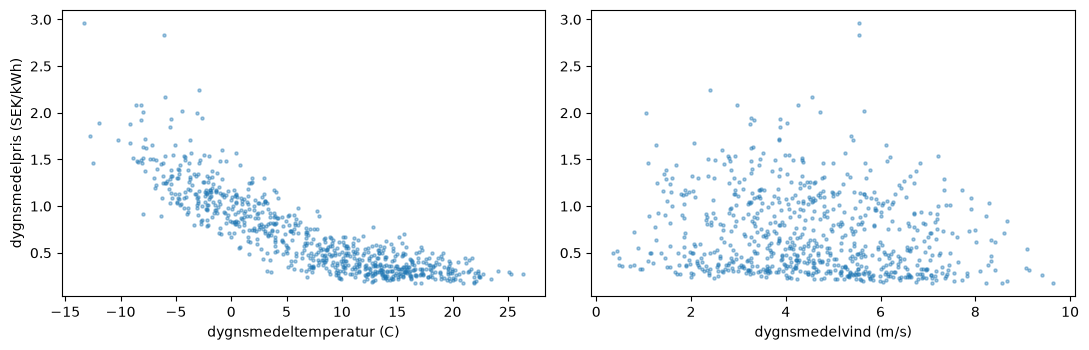

In [14]:
väder_dygn = väder.groupby("datum").agg(
    temp_mean=("temp_c", "mean"),
    temp_min=("temp_c", "min"),
    vind_mean=("vind_ms", "mean"),
    n_obs=("temp_c", "size"),
)
väder_dygn.index = pd.to_datetime(väder_dygn.index)

ihop = dygn.join(väder_dygn, how="left")
print(f"{ihop['temp_mean'].isna().sum()} dygn utan väderdata alls")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].scatter(ihop["temp_mean"], ihop["mean"], s=5, alpha=0.4)
axes[0].set_xlabel("dygnsmedeltemperatur (C)")
axes[0].set_ylabel("dygnsmedelpris (SEK/kWh)")
axes[1].scatter(ihop["vind_mean"], ihop["mean"], s=5, alpha=0.4)
axes[1].set_xlabel("dygnsmedelvind (m/s)")
plt.tight_layout()

In [15]:
print(ihop[["mean", "max", "temp_mean", "temp_min", "vind_mean"]].corr()["mean"].round(3))

mean         1.000
max          0.681
temp_mean   -0.856
temp_min    -0.820
vind_mean   -0.154
Name: mean, dtype: float64


Kallt väder driver upp priset, blåsigt väder drar ner det. Sambandet är tydligt men
långt ifrån deterministiskt, och det är svagare på sommaren än på vintern.

## 7. Informationsgränsen

Det här är det viktigaste avsnittet i notebooken.

När ni gör en prediktion en given dag D vet ni:

- priser som faktiskt observerats till och med D
- väder som faktiskt observerats till och med D
- en **prognos** för morgondagens väder

Ni vet **inte** morgondagens priser. Källan publicerar dem först runt
13:00 dag D.

`train.py` använder morgondagens *observerade* temperatur som stand-in för
morgondagens *prognos*. Det är acceptabelt att göra när man tränar men
i verkligheten har man bara en prognos att gå på, inte den faktiska temperaturen.
Modellen ser därför bättre ut här än den presterar i verkligheten.

Experimentet nedan lägger brus på prognosfeaturen för att mäta hur mycket
det spelar roll. 

På den syntetiska datan är effekten liten — gårdagens pris har redan det
mesta av informationen om årstid och väderläge, så en sämre temperatur-
prognos gör förvånansvärt lite skada. Det är i sig ett resultat värt att
förstå: features kan vara starkt överlappande, och en feature som
korrelerar tydligt med målet kan ändå tillföra nästan ingenting utöver de
andra.

Kör om samma experiment på riktig data och jämför. Blir svaret ett annat?

In [16]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

d = ihop.copy()
d["tomorrow_temp_mean"] = d["temp_mean"].shift(-1)
d["price_today"] = d["mean"]
d["price_yesterday"] = d["mean"].shift(1)
d["y"] = d["mean"].shift(-1)
d = d.dropna(subset=["y", "price_yesterday"])

F = ["tomorrow_temp_mean", "price_today", "price_yesterday"]
cut = int(len(d) * 0.8)
tr, te = d.iloc[:cut], d.iloc[cut:]

m = HistGradientBoostingRegressor(random_state=0).fit(tr[F], tr["y"])
print(f"perfekt 'prognos':  MAE {mean_absolute_error(te['y'], m.predict(te[F])):.4f}")

rng = np.random.default_rng(0)
for brus in (0.5, 1.0, 2.0, 3.0):
    te2 = te.copy()
    te2["tomorrow_temp_mean"] += rng.normal(0, brus, len(te2))
    mae = mean_absolute_error(te2["y"], m.predict(te2[F]))
    print(f"prognosfel {brus:.1f} C:  MAE {mae:.4f}")

perfekt 'prognos':  MAE 0.0672
prognosfel 0.5 C:  MAE 0.0673
prognosfel 1.0 C:  MAE 0.0682
prognosfel 2.0 C:  MAE 0.0672
prognosfel 3.0 C:  MAE 0.0684


## Vad ni ska ta med er

1. Ett dygn har inte 24 rader. Ibland har det 96, ibland 23 eller 25.
2. Två källor, två tidskonventioner. Fel här kan kosta utan att synas.
3. Luckor och dubbletter finns. Besluta hur ni hanterar dem, och skriv ner varför.
4. När modellen är i drift har ni en prognos, inte facit. Utvärdera därefter.
5. Jämför alltid mot "imorgon blir som idag". En modell som inte slår den
   är inte en stark modell.

Nästa steg: `model/train.py`, och avsnittet LIMITATIONS längst ner i den.